In [1]:
from subprocess import run
import pandas as pd
import os
from nilearn import datasets,image, surface, plotting
import nibabel as nib
import numpy as np
import plotly.io as pio  # Import plotly.io for exporting images
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats



/home/xy6/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Wedge

def plot_circle_with_filled_sectors(flags):
    # Create a figure and axis
    fig, ax = plt.subplots(subplot_kw={'aspect': 'equal'})
    
    angle_off = 45*2
    # Draw the circle
    circle = plt.Circle((0.5, 0.5), 0.5, color='black', fill=False)
    ax.add_artist(circle)
    
    # Divide the circle into 8 equal sectors
    angles = np.linspace(0, 2 * np.pi, 9)
    
    # Iterate over all sectors to draw borders
    for i in range(1, 9):
        # Calculate the start and end angles for the sector
        start_angle = np.degrees(angles[i - 1])+angle_off
        end_angle = np.degrees(angles[i])+angle_off
        
        # Draw the sector with a black border
        wedge = Wedge((0.5, 0.5), 0.5, start_angle, end_angle, facecolor='none', edgecolor='black', linewidth=4)
        ax.add_patch(wedge)
    
    # Iterate over the flags to fill sectors with color
    for flag in flags.split():
        sector = int(flag[:-1])  # Extract sector number
        color = 'red' if flag[-1] == '+' else 'blue'  # Determine color
        
        # Calculate the start and end angles for the sector
        start_angle = np.degrees(angles[sector - 1])+angle_off
        end_angle = np.degrees(angles[sector])+angle_off
        
        # Draw the sector with color and black border
        wedge = Wedge((0.5, 0.5), 0.5, start_angle, end_angle, facecolor=color, edgecolor='black', linewidth=4,alpha=0.7)
        ax.add_patch(wedge)
    
    # Add piece index at the center of each sector
    for i in range(1, 9):
        # Calculate the midpoint angle of the sector
        mid_angle = np.degrees((angles[i - 1] + angles[i]) / 2)+angle_off
        
        # Convert the midpoint angle to radians for calculation
        mid_angle_rad = np.radians(mid_angle)
        
        # Calculate the position for the text (slightly inside the circle)
        text_x = 0.5 + 0.3 * np.cos(mid_angle_rad)  # 0.3 is the offset from the center
        text_y = 0.5 + 0.3 * np.sin(mid_angle_rad)
        
        # Add the text
        ax.text(text_x, text_y, str(i), ha='center', va='center', fontsize=60, color='black')
    
    # Set limits and remove axes
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # Show the plot
    plt.show()



In [3]:
Dir_github = '/work/desai-lab/xuanyang/Project/Semantic/analysis/FactorAnalysis/github/FactorAnalysis_fMRI/scripts/'
Dir_mask = os.path.join(Dir_github,'fMRI','masks')

file_atlas = os.path.join(Dir_mask,'rs_HCPex.nii.gz')
img_atlas = image.load_img(file_atlas)
data_atlas = img_atlas.get_fdata()

file_mask = '/work/desai-lab/xuanyang/Project/Semantic/analysis/FactorAnalysis/github/FactorAnalysis_fMRI/scripts/fMRI/masks/rs_mask_GM_33.nii.gz'
img_mask = image.load_img(file_mask)
data_mask = img_mask.get_fdata()

data_atlas[data_mask==0] = 0

# df_atlas = pd.read_csv('/work/xy6/templates/HCPex_v1.1/HCPex_LookUpTable.txt',sep='\t')
# df_atlas = df_atlas.loc[df_atlas['#No.']!=0]
# df_atlas

# load atlas
df_atlas = pd.read_excel('/work/xy6/templates/HCPex_v1.1/Lookuptable.xlsx')
df_atlas[['idx_L','idx_R']] = df_atlas['Reordered'].str.split(', ',expand=True)
df_atlas = df_atlas.melt(id_vars=['Reordered','Region','RegionLongName','Cortical Division','Cortex','Original','Voxel numbers'],
              value_vars = ['idx_L','idx_R'],
              var_name = 'LR',
             value_name = 'idx')
df_atlas['#No.'] = df_atlas['idx'].astype(float)
# df_atlas.rename({'idx':'#No.'},axis=1,inplace=True)
df_atlas


,Reordered,Region,RegionLongName,Cortical Division,Cortex,Original,Voxel numbers,LR,idx,#No.
0,"1, 181",V1,Primary_Visual_Cortex,Primary_Visual,1.0,1.0,"13,812, 13,406",idx_L,1,1.0
1,"2, 182",V2,Second_Visual_Area,Early_Visual,2.0,4.0,"9515, 9420",idx_L,2,2.0
2,"3, 183",V3,Third_Visual_Area,Early_Visual,2.0,5.0,"7106, 7481",idx_L,3,3.0
3,"4, 184",V4,Fourth_Visual_Area,Early_Visual,2.0,6.0,"4782, 4537",idx_L,4,4.0
4,"5, 185",IPS1,IntraParietal_Sulcus_Area_1,Dorsal_Stream_Visual,3.0,17.0,"1751, 1750",idx_L,5,5.0
...,...,...,...,...,...,...,...,...,...,...
421,"389, 422",SNpr,Substantia nigra pars reticulata,NaN,NaN,NaN,"408, 440",idx_R,422,422.0
422,"390, 423",VTA,Ventral tegmental area,NaN,NaN,NaN,"40, 48",idx_R,423,423.0
423,"391, 424",MB,Mammillary bodies,NaN,NaN,NaN,"112, 104",idx_R,424,424.0
424,"392, 425",Septum,Septal nuclei,NaN,NaN,NaN,"248, 136",idx_R,425,425.0


In [36]:
df_atlas.loc[df_atlas['#No.'].isin([360,249])]

,Reordered,Region,RegionLongName,Cortical Division,Cortex,Original,Voxel numbers,LR,idx,#No.
281,"69, 249",AVI,Anterior_Ventral_Insular_Area,Insula_FrontalOperc,12.0,111.0,"1446, 1792",idx_R,249,249.0
392,"180, 360",SFL,Superior_Frontal_Language_Area,Dorsolateral_Prefrontal,22.0,26.0,"3873, 3055",idx_R,360,360.0


In [4]:
Dir_working = '/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/FactorAnalysis'
Nvar = 113
NFA = 8
flag_model = f'Nvar{Nvar}NFA{NFA}_LPAC_multipleReg_unsmoothed'
atlas_name = 'HCPex'
folder = 'nonthreshold_LMEr_r1.3'

Dir_model = os.path.join(Dir_working,'models',flag_model,f'FA{NFA}_{atlas_name}')
Dir_results = os.path.join(Dir_model,'results')
Dir_results_1st = os.path.join(Dir_results,'firstlevel')
Dir_results_2nd = os.path.join(Dir_results,'secondlevel')


In [14]:
df_results = []
p_value = 0.001
z_thresh = stats.norm.ppf(1 - p_value)  # One-tailed (upper tail)

# data = dict()
for iFA in range(1,NFA+1):
        
    file_FA = os.path.join(Dir_results_2nd,folder,f"FA{iFA}+orig.BRIK.gz")
    
    if '.nii' in file_FA:
        img_FA = image.load_img(file_FA)
    else:
        img_FA = image.index_img(file_FA, 4) 

    data_FA = img_FA.get_fdata()
    if iFA == 7:
        data_FA = data_FA*-1
        
    data_threshold = data_FA.copy()
    data_threshold[np.abs(data_threshold)<=z_thresh] = 0

    for i,roi in enumerate(np.unique(data_atlas)):

        roi_values = data_threshold[(data_atlas==roi)&(data_mask==1)]
        sig = 1 if roi_values[roi_values!=0].shape[0]>0 else 0
        label = np.nan
        if roi_values[0]>0:
            
            label = '+'
        elif roi_values[0]<0:
            label = '-'
        
        df_tmp = pd.DataFrame({'iFA':iFA,'ROI_idx':roi,'ROI_value':data_FA[(data_atlas==roi)&(data_mask==1)][0],
                               'significant':sig,'alpha':p_value,'label':label},index=[0])
        df_results.append(df_tmp)
df_results = pd.concat(df_results,ignore_index=True)
df_results['p_value'] = stats.norm.sf(df_results['ROI_value'].abs())
df_results = df_results.loc[(df_results['ROI_idx']!=0)&(df_results['ROI_idx']<=360)]

In [15]:
alpha_FDR = .005
df_results['alpha_FDR'] = alpha_FDR
for iFA in range(1,8+1):
    df_results.loc[df_results['iFA']==iFA,'p_value_FDR'] = stats.false_discovery_control(df_results.loc[df_results['iFA']==iFA,'p_value'])
df_results['significant_FDR'] = 0
df_results.loc[df_results['p_value_FDR']<alpha_FDR,'significant_FDR'] = 1
df_results.loc[df_results['significant_FDR']==1,'label_FDR'] = df_results.loc[df_results['significant_FDR']==1,'label']

# df_results_wide = df_results.pivot(index='ROI_idx',columns='iFA',values='label').dropna(how='all')
# df_results_wide


In [16]:
df_output = pd.merge(left = df_results, left_on = 'ROI_idx',
         right = df_atlas, right_on = '#No.',how='left')
dir_output = '/work/desai-lab/xuanyang/Project/Semantic/analysis/FactorAnalysis/github/FactorAnalysis_fMRI/data/HCPex_p001/'
df_output.to_csv(os.path.join(dir_output,'df_ROIvalue_HCPex_p005FDR_unsmoothed_LMEr_r1.3.csv'),index=False)

In [50]:
dir_output

'/work/desai-lab/xuanyang/Project/Semantic/analysis/FactorAnalysis/github/FactorAnalysis_fMRI/data/HCPex_p001/'

In [17]:
df_output.loc[df_output['significant_FDR']==1]

,iFA,ROI_idx,ROI_value,significant,alpha,label,p_value,alpha_FDR,p_value_FDR,significant_FDR,...,Reordered,Region,RegionLongName,Cortical Division,Cortex,Original,Voxel numbers,LR,idx,#No.
10,1,11.0,-4.729296,1,0.001,-,1.126500e-06,0.005,3.379500e-05,1,...,"11, 191",FFC,Fusiform_Face_Complex,Ventral_Stream_Visual,4.0,18.0,"3848, 4402",idx_L,11,11.0
36,1,37.0,3.571455,1,0.001,+,1.775021e-04,0.005,2.282170e-03,1,...,"37, 217",5mv,Area_5m_ventral,ParaCentral_MidCing,7.0,37.0,"1651, 1996",idx_L,37,37.0
48,1,49.0,3.778115,1,0.001,+,7.900994e-05,0.005,1.412641e-03,1,...,"49, 229",FOP1,Frontal_Opercular_Area_1,Posterior_Opercular,9.0,113.0,"879, 932",idx_L,49,49.0
59,1,60.0,-6.074168,1,0.001,-,6.231602e-10,0.005,9.159028e-08,1,...,"60, 240",A4,Auditory_4_Complex,Auditory_Association,11.0,175.0,"3514, 3610",idx_L,60,60.0
60,1,61.0,-6.041540,1,0.001,-,7.632523e-10,0.005,9.159028e-08,1,...,"61, 241",A5,Auditory_5_Complex,Auditory_Association,11.0,125.0,"3346, 3881",idx_L,61,61.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2799,8,280.0,-5.610442,1,0.001,-,1.009054e-08,0.005,1.210865e-06,1,...,"100, 280",TPOJ3,Area_TemporoParietoOccipital_Junction_3,TPO,15.0,141.0,"1290, 1277",idx_R,280,280.0
2829,8,310.0,3.520365,1,0.001,+,2.154770e-04,0.005,2.983528e-03,1,...,"130, 310",POS2,Parieto-Occipital_Sulcus_Area_2,Posterior_Cingulate,18.0,15.0,"3261, 3093",idx_R,310,310.0
2832,8,313.0,3.359683,1,0.001,+,3.901597e-04,0.005,4.712601e-03,1,...,"133, 313",v23ab,Area_ventral_23_a + b,Posterior_Cingulate,18.0,33.0,"916, 1089",idx_R,313,313.0
2833,8,314.0,3.421407,1,0.001,+,3.114899e-04,0.005,4.004870e-03,1,...,"134, 314",10r,Area_10r,AntCing_MedPFC,19.0,65.0,"1589, 1053",idx_R,314,314.0


In [18]:
df_conjunction = [] # FDR corrected
for i,roi in enumerate(np.unique(data_atlas)):
    df = df_results.loc[df_results['ROI_idx']==roi]
    df = df.loc[~df['label_FDR'].isna()] 
    flag = ' '.join(df['iFA'].astype(str)+df['label_FDR'])
    if df.shape[0]>0:
        df_conjunction.append(pd.DataFrame({'ROI_idx':roi,'n':df.shape[0],
                                                'FA':''.join(df['iFA'].astype(str)),'flag':flag},index=[0]))
            # print(flag)
df_conjunction = pd.concat(df_conjunction)
df_conjunction = pd.merge(left=df_conjunction,left_on='ROI_idx',
                          right=df_atlas[['#No.','Region','RegionLongName','Cortical Division']],
                          right_on='#No.',how='left')
df_conjunction.sort_values(['n'],ascending=False,inplace=True)
df_conjunction = df_conjunction.loc[df_conjunction['ROI_idx']!=0]

df_conjunction.loc[df_conjunction['Cortical Division'].isna(),'Cortical Division'] = 'Subcortical'
df_conjunction

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
131,241.0,6,124678,1- 2- 4+ 6- 7+ 8+,241.0,A5,Auditory_5_Complex,Auditory_Association
153,277.0,6,123468,1+ 2- 3- 4+ 6+ 8-,277.0,STV,Superior_Temporal_Visual_Area,TPO
134,244.0,6,234678,2- 3- 4+ 6- 7+ 8+,244.0,STSdp,Area_STSd_posterior,Auditory_Association
130,240.0,4,2468,2- 4+ 6- 8+,240.0,A4,Auditory_4_Complex,Auditory_Association
135,246.0,4,2346,2- 3- 4+ 6-,246.0,STSvp,Area_STSv_posterior,Auditory_Association
...,...,...,...,...,...,...,...,...
83,135.0,1,8,8+,135.0,10v,Area_10v,AntCing_MedPFC
84,137.0,1,6,6+,137.0,33pr,Area_33_prime,AntCing_MedPFC
86,143.0,1,2,2-,143.0,d32,Area_dorsal_32,AntCing_MedPFC
87,145.0,1,6,6+,145.0,p24pr,Area_Posterior_24_prime,AntCing_MedPFC


In [19]:
Dir_output = os.path.join(Dir_results_2nd,'threshold_p005FDR','conjunction','gradiant')
os.makedirs(Dir_output,exist_ok=True)
df_conjunction.to_csv(os.path.join(Dir_output,'table_atlas&radar_labeled_005FDR_unsmoothed_LMEr_r1.3.csv'),index=False)

In [18]:
Dir_output = os.path.join(Dir_results_2nd,'threshold_p005FDR','conjunction','gradiant')
Dir_output

'/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/FactorAnalysis/models/Nvar113NFA8_LPAC_multipleReg_unsmoothed/FA8_HCPex/results/secondlevel/threshold_p005FDR/conjunction/gradiant'

### Domain-general Core (Assem et al., 2020)

In [26]:
List_DM_core = ['8C','8BM','AVI','PFm','i6-8','IFJp','a9-46v','IP1','p9-46v','IP2','a9-46v']
List_DM_extend = List_DM_core+['PGs','a47r','d32','p 10p','FOP5','SCEF','TE1p','TE1m','11l','a10p','s6-8',
                              '6r','a32pr','p47r','POS2','AIP','MIP','LIPd']

df_conjunction.loc[df_conjunction['Region'].isin(List_DM_core)]

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
92,164.0,3,167,1- 6+ 7+,164.0,IFJp,Area_IFJp,Inferior_Frontal
102,176.0,2,12,1- 2-,176.0,a9-46v,Area_anterior_9-46v,Dorsolateral_Prefrontal
104,178.0,2,16,1- 6+,178.0,p9-46v,Area_posterior_9-46v,Dorsolateral_Prefrontal
167,318.0,1,2,2-,318.0,8BM,Area_8BM,AntCing_MedPFC
66,112.0,1,6,6+,112.0,IP1,Area_IntraParietal_1,Inferior_Parietal
67,113.0,1,6,6+,113.0,IP2,Area_IntraParietal_2,Inferior_Parietal
69,115.0,1,2,2-,115.0,PFm,Area_PFm_Complex,Inferior_Parietal
103,177.0,1,6,6+,177.0,i6-8,Inferior_6-8_Transitional_Area,Dorsolateral_Prefrontal
131,249.0,1,5,5+,249.0,AVI,Anterior_Ventral_Insular_Area,Insula_FrontalOperc
176,344.0,1,6,6+,344.0,IFJp,Area_IFJp,Inferior_Frontal


### By function

In [17]:
df_conjunction.loc[~df_conjunction['flag'].str.contains('|'.join(['6','7','8']))].sort_values(['Cortical Division']).head(50)

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
197,319.0,1,3,3-,319.0,9 m,Area_9_Middle,AntCing_MedPFC
96,138.0,1,5,5+,138.0,8BM,Area_8BM,AntCing_MedPFC
98,143.0,1,2,2-,143.0,d32,Area_dorsal_32,AntCing_MedPFC
198,324.0,1,5,5+,324.0,p24,Area_posterior_24,AntCing_MedPFC
196,318.0,1,2,2-,318.0,8BM,Area_8BM,AntCing_MedPFC
38,60.0,1,1,1-,60.0,A4,Auditory_4_Complex,Auditory_Association
3,10.0,1,5,5+,10.0,V7,Seventh_Visual_Area,Dorsal_Stream_Visual
211,349.0,1,5,5-,349.0,8Ad,Area_8Ad,Dorsolateral_Prefrontal
117,175.0,1,3,3-,175.0,9p,Area_9_Posterior,Dorsolateral_Prefrontal
118,176.0,2,12,1- 2-,176.0,a9-46v,Area_anterior_9-46v,Dorsolateral_Prefrontal


### By region

#### # vOTC/fusiform/parahippocampal

To map onto the brain, use x = -46, y=-50

In [9]:
pd.set_option('future.no_silent_downcasting', True)

In [45]:

Dir_output = os.path.join(Dir_results_2nd,'threshold_p001','conjunction','bar_gradiant')
Dir_output


'/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/FactorAnalysis/models/Nvar113NFA8_LPAC_multipleReg/FA8_HCPex/results/secondlevel/threshold_p001/conjunction/bar_gradiant'

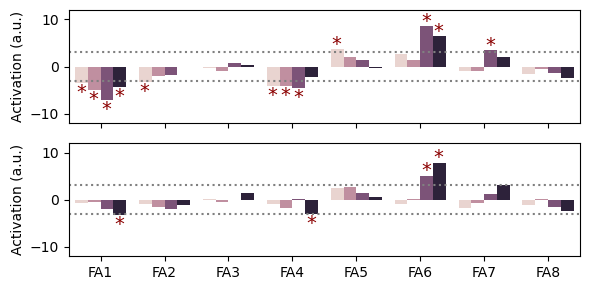

In [46]:


fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize=(6,3),sharex=True,sharey=True)  # or use your existing axes

List_idx_L = [24,11,93,84]
List_idx_R = [x+180 for x in List_idx_L]
for ax, List_idx in zip(axes.flatten(),[List_idx_L,List_idx_R]):
    
    df_plot = df_results.loc[df_results['ROI_idx'].isin(List_idx)].copy()
    df_plot['ROI_idx'] = df_plot['ROI_idx'].astype(int).astype(str)

    df_plot['order'] = df_plot['ROI_idx'].copy()
    dict_mapping = {str(v): i+1 for i, v in enumerate(List_idx)}
    df_plot['order'] = df_plot['order'].replace(dict_mapping)
    


    sns.barplot(data=df_plot, x='iFA', y='ROI_value', 
                ax=ax, hue='order', #hue_order=[str(x) for x in List_idx],
               )
    
    # Annotate each bar
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if abs(height) > z_thresh:
                x = bar.get_x() + bar.get_width() / 2 -0.01
                y = height - 1 if height > 0 else height - 0.02
                va = 'bottom' if height > 0 else 'top'
                ax.text(x, y, '*', ha='center', va=va, color='darkred', fontsize=14)

    ax.set(ylabel='Activation (a.u.)',
           xlabel="",ylim=[-12,12])
    ax.set_xticks(range(8), labels=[f"FA{x+1}" for x in range(8)])
    
    # Move the legend outside to the right
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    ax.get_legend().set_visible(False)
    
    ax.axhline(y=z_thresh,color = 'grey',linestyle=':')
    ax.axhline(y=z_thresh*-1,color = 'grey',linestyle=':')
    # Adjust the figure to make room for the legend
plt.tight_layout()

plt.show()# df_plot
filename = f"fig_bargradient_vOTC.jpg"
fig.savefig(os.path.join(Dir_output,filename),bbox_inches='tight')

In [32]:
height

-2.4950642585754395

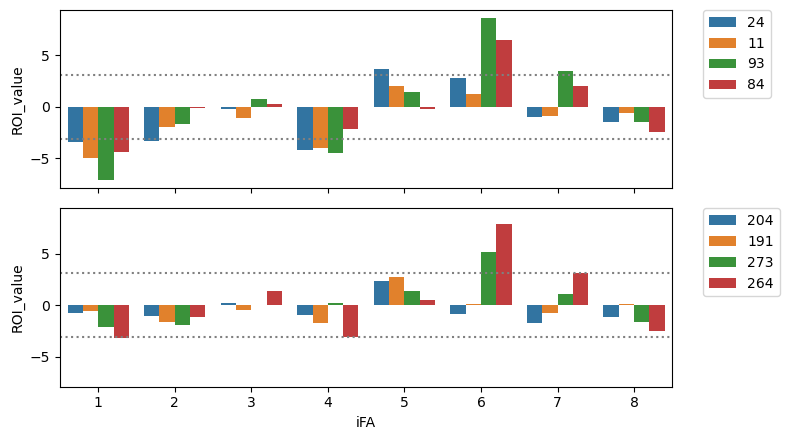

In [10]:


fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize=(8,4.5),sharex=True,sharey=True)  # or use your existing axes

List_idx_L = [24,11,93,84]
List_idx_R = [x+180 for x in List_idx_L]
for ax, List_idx in zip(axes.flatten(),[List_idx_L,List_idx_R]):
    
    df_plot = df_results.loc[df_results['ROI_idx'].isin(List_idx)].copy()
    df_plot['ROI_idx'] = df_plot['ROI_idx'].astype(int).astype(str)



    sns.barplot(data=df_plot, x='iFA', y='ROI_value', 
                ax=ax, hue='ROI_idx', hue_order=[str(x) for x in List_idx],
               )

    # Move the legend outside to the right
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    ax.axhline(y=z_thresh,color = 'grey',linestyle=':')
    ax.axhline(y=z_thresh*-1,color = 'grey',linestyle=':')
    # Adjust the figure to make room for the legend
plt.tight_layout()

plt.show()# df_plot

#### IFG

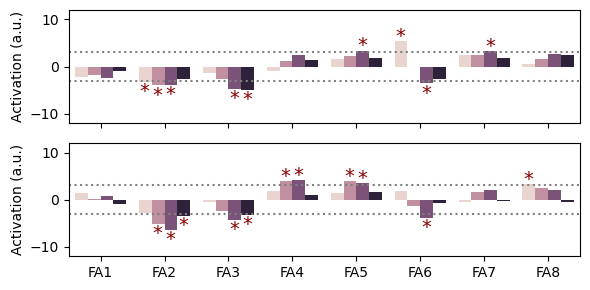

In [47]:


fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize=(6,3),sharex=True,sharey=True)  # or use your existing axes

List_idx_L = [44,159,160,161]
List_idx_R = [x+180 for x in List_idx_L]
for ax, List_idx in zip(axes.flatten(),[List_idx_L,List_idx_R]):
    
    df_plot = df_results.loc[df_results['ROI_idx'].isin(List_idx)].copy()
    df_plot['ROI_idx'] = df_plot['ROI_idx'].astype(int).astype(str)

    df_plot['order'] = df_plot['ROI_idx'].copy()
    dict_mapping = {str(v): i+1 for i, v in enumerate(List_idx)}
    df_plot['order'] = df_plot['order'].replace(dict_mapping)
    


    sns.barplot(data=df_plot, x='iFA', y='ROI_value', 
                ax=ax, hue='order', #hue_order=[str(x) for x in List_idx],
               )
    
    # Annotate each bar
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if abs(height) > z_thresh:
                x = bar.get_x() + bar.get_width() / 2 -0.01
                y = height - 1 if height > 0 else height - 0.02
                va = 'bottom' if height > 0 else 'top'
                ax.text(x, y, '*', ha='center', va=va, color='darkred', fontsize=14)

    ax.set(ylabel='Activation (a.u.)',
           xlabel="",ylim=[-12,12])
    ax.set_xticks(range(8), labels=[f"FA{x+1}" for x in range(8)])
    
    # Move the legend outside to the right
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    ax.get_legend().set_visible(False)
    
    ax.axhline(y=z_thresh,color = 'grey',linestyle=':')
    ax.axhline(y=z_thresh*-1,color = 'grey',linestyle=':')
    # Adjust the figure to make room for the legend
plt.tight_layout()

plt.show()# df_plot
filename = f"fig_bargradient_IFG.jpg"
fig.savefig(os.path.join(Dir_output,filename),bbox_inches='tight')

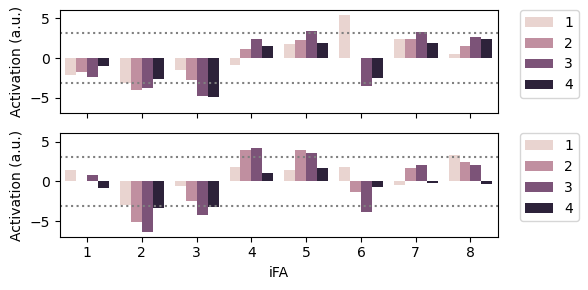

In [13]:
# precentral-> IFJ/IFS, IFG-Oper -> IFG-Orb
# x = -52

fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize=(6,3),sharex=True,sharey=True)  # or use your existing axes

List_idx_L = [44,159,160,161]
List_idx_R = [x+180 for x in List_idx_L]
for ax, List_idx in zip(axes.flatten(),[List_idx_L,List_idx_R]):
    
    df_plot = df_results.loc[df_results['ROI_idx'].isin(List_idx)].copy()
    df_plot['ROI_idx'] = df_plot['ROI_idx'].astype(int).astype(str)

    df_plot['order'] = df_plot['ROI_idx'].copy()
    dict_mapping = {str(v): i+1 for i, v in enumerate(List_idx)}
    df_plot['order'] = df_plot['order'].replace(dict_mapping)
    


    sns.barplot(data=df_plot, x='iFA', y='ROI_value', 
                ax=ax, hue='order', #hue_order=[str(x) for x in List_idx],
               )
    ax.set(ylabel='Activation (a.u.)')

    # Move the legend outside to the right
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    ax.axhline(y=z_thresh,color = 'grey',linestyle=':')
    ax.axhline(y=z_thresh*-1,color = 'grey',linestyle=':')
    # Adjust the figure to make room for the legend
plt.tight_layout()

plt.show()# df_plot

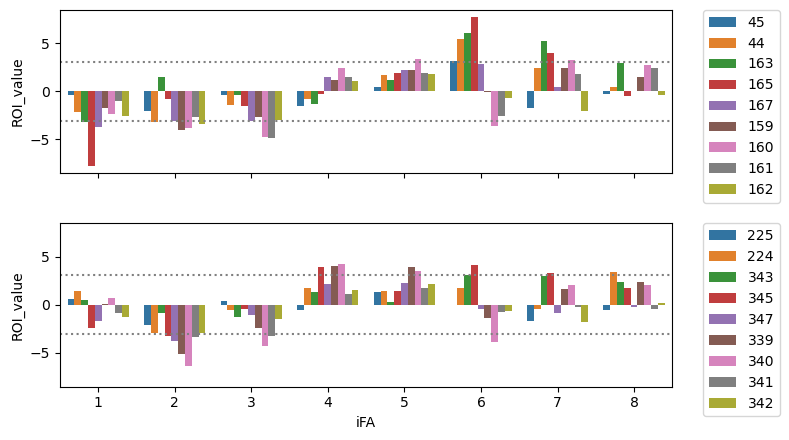

In [72]:
# precentral-> IFJ/IFS, IFG-Oper -> IFG-Orb
# x = -52
fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize=(8,4.5),sharex=True,sharey=True)  # or use your existing axes

List_idx_L = [45,44,163,165,167,159,160,161,162]
List_idx_R = [x+180 for x in List_idx_L]
for ax, List_idx in zip(axes.flatten(),[List_idx_L,List_idx_R]):
    
    df_plot = df_results.loc[df_results['ROI_idx'].isin(List_idx)].copy()
    df_plot['ROI_idx'] = df_plot['ROI_idx'].astype(int).astype(str)



    sns.barplot(data=df_plot, x='iFA', y='ROI_value', 
                ax=ax, hue='ROI_idx', hue_order=[str(x) for x in List_idx],
               )

    # Move the legend outside to the right
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    ax.axhline(y=z_thresh,color = 'grey',linestyle=':')
    ax.axhline(y=z_thresh*-1,color = 'grey',linestyle=':')
    # Adjust the figure to make room for the legend
plt.tight_layout()

plt.show()# df_plot

#### AG

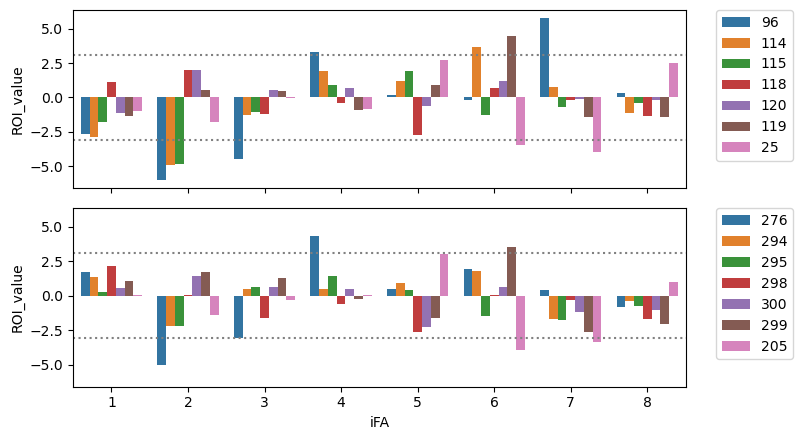

In [75]:
# PSL - SMG - AG - LOC
# 
fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize=(8,4.5),sharex=True,sharey=True)  # or use your existing axes

List_idx_L = [96,114,115,118,120,119,25]
List_idx_R = [x+180 for x in List_idx_L]
for ax, List_idx in zip(axes.flatten(),[List_idx_L,List_idx_R]):
    
    df_plot = df_results.loc[df_results['ROI_idx'].isin(List_idx)].copy()
    df_plot['ROI_idx'] = df_plot['ROI_idx'].astype(int).astype(str)



    sns.barplot(data=df_plot, x='iFA', y='ROI_value', 
                ax=ax, hue='ROI_idx', hue_order=[str(x) for x in List_idx],
               )

    # Move the legend outside to the right
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    ax.axhline(y=z_thresh,color = 'grey',linestyle=':')
    ax.axhline(y=z_thresh*-1,color = 'grey',linestyle=':')
    # Adjust the figure to make room for the legend
plt.tight_layout()

plt.show()# df_plot

#### PCC

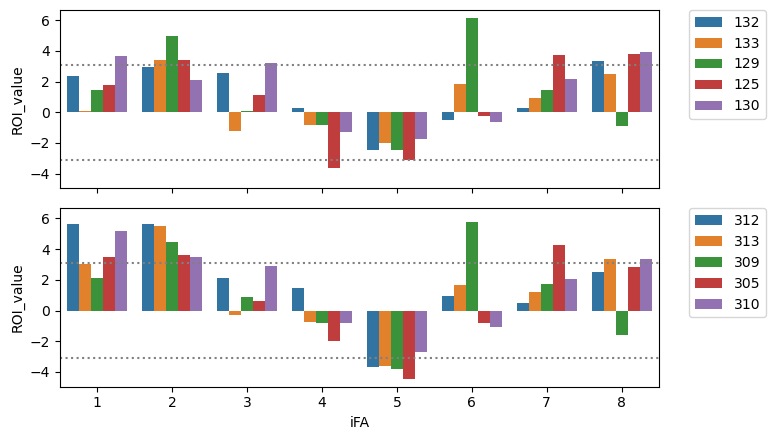

In [77]:
# PSL - SMG - AG - LOC
# 
fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize=(8,4.5),sharex=True,sharey=True)  # or use your existing axes

List_idx_L = [132,133,129,125,130]
List_idx_R = [x+180 for x in List_idx_L]
for ax, List_idx in zip(axes.flatten(),[List_idx_L,List_idx_R]):
    
    df_plot = df_results.loc[df_results['ROI_idx'].isin(List_idx)].copy()
    df_plot['ROI_idx'] = df_plot['ROI_idx'].astype(int).astype(str)



    sns.barplot(data=df_plot, x='iFA', y='ROI_value', 
                ax=ax, hue='ROI_idx', hue_order=[str(x) for x in List_idx],
               )

    # Move the legend outside to the right
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    ax.axhline(y=z_thresh,color = 'grey',linestyle=':')
    ax.axhline(y=z_thresh*-1,color = 'grey',linestyle=':')
    # Adjust the figure to make room for the legend
plt.tight_layout()

plt.show()# df_plot

In [11]:
# STG/STS
List_regions = ['Auditory']
df_conjunction.loc[df_conjunction['Cortical Division'].str.contains('|'.join(List_regions))].sort_values('ROI_idx')

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
35,53.0,1,2,2-,53.0,52,Area_52,Early_Auditory
36,54.0,2,48,4- 8-,54.0,A1,Primary_Auditory_Cortex,Early_Auditory
37,58.0,1,2,2-,58.0,PFcm,Area_PFcm,Early_Auditory
38,60.0,1,1,1-,60.0,A4,Auditory_4_Complex,Auditory_Association
39,61.0,3,168,1- 6- 8+,61.0,A5,Auditory_5_Complex,Auditory_Association
40,62.0,3,368,3- 6- 8+,62.0,STGa,Area_STGa,Auditory_Association
41,63.0,2,36,3- 6-,63.0,STSda,Area_STSd_anterior,Auditory_Association
42,64.0,2,36,3- 6-,64.0,STSdp,Area_STSd_posterior,Auditory_Association
43,66.0,2,36,3- 6-,66.0,STSvp,Area_STSv_posterior,Auditory_Association
44,67.0,2,28,2- 8+,67.0,TA2,Area_TA2,Auditory_Association


In [29]:
List_idx = [62,94,95]
df_conjunction.loc[df_conjunction['ROI_idx'].isin(List_idx)].sort_values('ROI_idx')

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
40,62.0,3,368,3- 6- 8+,62.0,STGa,Area_STGa,Auditory_Association
67,94.0,1,3,3-,94.0,TGd,Area_TG_dorsal,Lateral_Temporal
68,95.0,1,3,3-,95.0,TGv,Area_TG_Ventral,Lateral_Temporal


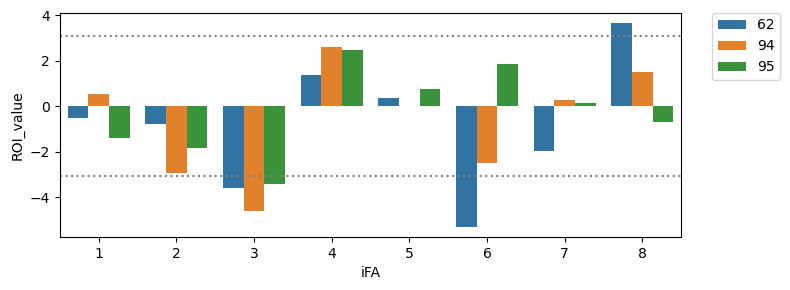

In [9]:
fig, ax = plt.subplots(figsize=(8,3))  

List_idx = [62,94,95]
df_plot = df_results.loc[df_results['ROI_idx'].isin(List_idx)].copy()
df_plot['ROI_idx'] = df_plot['ROI_idx'].astype(int).astype(str)
sns.barplot(data=df_plot, x='iFA', y='ROI_value', ax=ax, hue='ROI_idx', hue_order=[str(x) for x in List_idx])

# Move the legend outside to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.axhline(y=z_thresh,color = 'grey',linestyle=':')
ax.axhline(y=z_thresh*-1,color = 'grey',linestyle=':')
plt.tight_layout()

plt.show()# df_plot

In [12]:
# IFG/IFS/IFJ
# 165: IFSa more likely to be semantic


List_regions = ['Inferior_Frontal']
df_conjunction.loc[df_conjunction['Cortical Division'].str.contains('|'.join(List_regions))].sort_values('ROI_idx')

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
103,159.0,1,2,2-,159.0,44,Area_44,Inferior_Frontal
104,160.0,5,23567,2- 3- 5+ 6- 7+,160.0,45,Area_45,Inferior_Frontal
105,161.0,1,3,3-,161.0,47 l,Area_47l_(47_lateral),Inferior_Frontal
106,162.0,1,2,2-,162.0,a47r,Area_anterior_47r,Inferior_Frontal
107,163.0,3,167,1- 6+ 7+,163.0,IFJa,Area_IFJa,Inferior_Frontal
108,164.0,3,167,1- 6+ 7+,164.0,IFJp,Area_IFJp,Inferior_Frontal
109,165.0,3,167,1- 6+ 7+,165.0,IFSa,Area_IFSa,Inferior_Frontal
110,166.0,2,16,1- 6+,166.0,IFSp,Area_IFSp,Inferior_Frontal
111,167.0,3,123,1- 2- 3-,167.0,p47r,Area_posterior_47r,Inferior_Frontal
203,339.0,3,245,2- 4+ 5+,339.0,44,Area_44,Inferior_Frontal


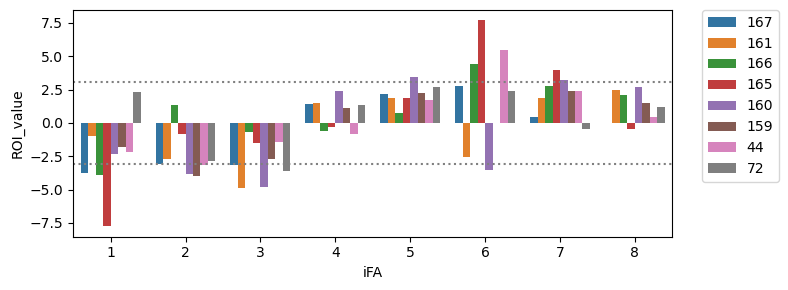

In [34]:
fig, ax = plt.subplots(figsize=(8,3))  

List_idx = [167,161,166,165,160,159,44,72]
df_plot = df_results.loc[df_results['ROI_idx'].isin(List_idx)].copy()
df_plot['ROI_idx'] = df_plot['ROI_idx'].astype(int).astype(str)
sns.barplot(data=df_plot, x='iFA', y='ROI_value', ax=ax, hue='ROI_idx', hue_order=[str(x) for x in List_idx])

# Move the legend outside to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.axhline(y=z_thresh,color = 'grey',linestyle=':')
ax.axhline(y=z_thresh*-1,color = 'grey',linestyle=':')
plt.tight_layout()

plt.show()# df_plot

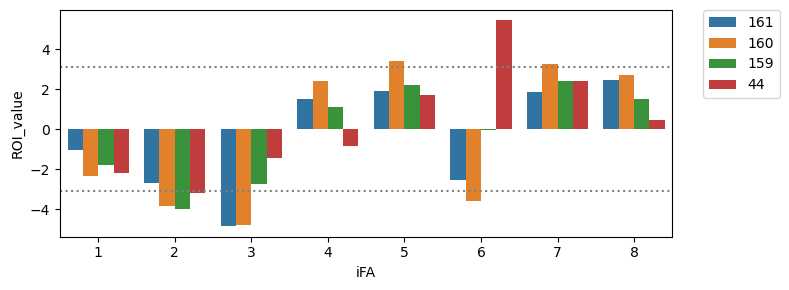

In [38]:
fig, ax = plt.subplots(figsize=(8,3))  

List_idx = [161,160,159,44]
df_plot = df_results.loc[df_results['ROI_idx'].isin(List_idx)].copy()
df_plot['ROI_idx'] = df_plot['ROI_idx'].astype(int).astype(str)
sns.barplot(data=df_plot, x='iFA', y='ROI_value', ax=ax, hue='ROI_idx', hue_order=[str(x) for x in List_idx])

# Move the legend outside to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.axhline(y=z_thresh,color = 'grey',linestyle=':')
ax.axhline(y=z_thresh*-1,color = 'grey',linestyle=':')
plt.tight_layout()

plt.show()# df_plot

In [39]:
List_idx = [161,160,159,44]
df_conjunction.loc[df_conjunction['ROI_idx'].isin(List_idx)].sort_values('ROI_idx')

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
29,44.0,2,26,2- 6+,44.0,6r,Rostral_Area_6,Premotor
103,159.0,1,2,2-,159.0,44,Area_44,Inferior_Frontal
104,160.0,5,23567,2- 3- 5+ 6- 7+,160.0,45,Area_45,Inferior_Frontal
105,161.0,1,3,3-,161.0,47 l,Area_47l_(47_lateral),Inferior_Frontal


In [13]:
# MTG/ ITG 
# bilateral TE1a, TE1m: semantic: 89,90,
List_regions = ['Lateral_Temporal']
df_conjunction.loc[df_conjunction['Cortical Division'].str.contains('|'.join(List_regions))].sort_values('ROI_idx')

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
62,88.0,4,1268,1- 2- 6+ 8-,88.0,PHT,Area_PHT,Lateral_Temporal
63,89.0,2,36,3- 6-,89.0,TE1a,Area_TE1_anterior,Lateral_Temporal
64,90.0,3,236,2- 3- 6-,90.0,TE1m,Area_TE1_Middle,Lateral_Temporal
65,91.0,2,15,1- 5+,91.0,TE1p,Area_TE1_posterior,Lateral_Temporal
66,93.0,4,1467,1- 4- 6+ 7+,93.0,TE2p,Area_TE2_posterior,Lateral_Temporal
67,94.0,1,3,3-,94.0,TGd,Area_TG_dorsal,Lateral_Temporal
68,95.0,1,3,3-,95.0,TGv,Area_TG_Ventral,Lateral_Temporal
171,268.0,1,2,2-,268.0,PHT,Area_PHT,Lateral_Temporal
172,269.0,1,6,6-,269.0,TE1a,Area_TE1_anterior,Lateral_Temporal
173,270.0,2,26,2- 6-,270.0,TE1m,Area_TE1_Middle,Lateral_Temporal


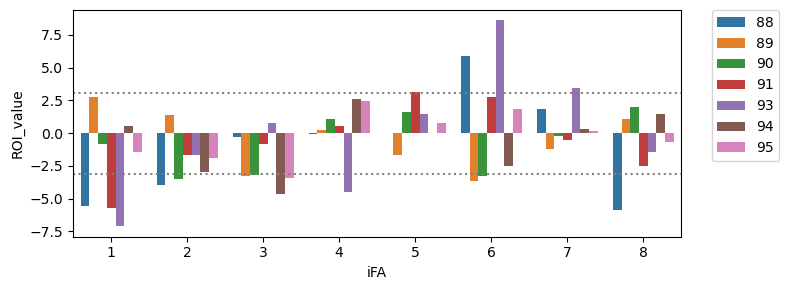

In [37]:
fig, ax = plt.subplots(figsize=(8,3))  

List_idx = [x for x in range(88,96) if x!=92]
df_plot = df_results.loc[df_results['ROI_idx'].isin(List_idx)].copy()
df_plot['ROI_idx'] = df_plot['ROI_idx'].astype(int).astype(str)
sns.barplot(data=df_plot, x='iFA', y='ROI_value', ax=ax, hue='ROI_idx', hue_order=[str(x) for x in List_idx])

# Move the legend outside to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.axhline(y=z_thresh,color = 'grey',linestyle=':')
ax.axhline(y=z_thresh*-1,color = 'grey',linestyle=':')
plt.tight_layout()

plt.show()# df_plot

In [58]:
df_conjunction['Cortical Division'].unique()

array(['Auditory_Association', 'TPO', 'Inferior_Frontal',
       'Lateral_Temporal', 'MT + _Complex', 'Subcortical',
       'Posterior_Cingulate', 'Dorsolateral_Prefrontal', 'OrbPolaFrontal',
       'Early_Auditory', 'Insula_FrontalOperc', 'ParaCentral_MidCing',
       'Medial_Temporal', 'Superior_Parietal', 'Inferior_Parietal',
       'AntCing_MedPFC', 'Premotor', 'Ventral_Stream_Visual',
       'Posterior_Opercular', 'Dorsal_Stream_Visual', 'Early_Visual',
       'SomaSens_Motor'], dtype=object)

In [14]:
# IPL
# AG: 119 semantic
# SMG: 114, 113 semantic
List_regions = ['Inferior_Parietal']
df_conjunction.loc[df_conjunction['Cortical Division'].str.contains('|'.join(List_regions))].sort_values('ROI_idx')

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
79,112.0,1,6,6+,112.0,IP1,Area_IntraParietal_1,Inferior_Parietal
80,113.0,1,6,6+,113.0,IP2,Area_IntraParietal_2,Inferior_Parietal
81,114.0,2,26,2- 6+,114.0,PF,Area_PF_Complex,Inferior_Parietal
82,115.0,1,2,2-,115.0,PFm,Area_PFm_Complex,Inferior_Parietal
83,119.0,1,6,6+,119.0,PGp,Area_PGp,Inferior_Parietal
183,299.0,1,6,6+,299.0,PGp,Area_PGp,Inferior_Parietal


In [15]:
df_conjunction.loc[df_conjunction['ROI_idx']==120]

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division


#### FA1

In [16]:
# IFJ/IFS is semantic
df_conjunction.loc[df_conjunction['FA'].str.contains('1')].loc[df_conjunction['Cortical Division']=='Inferior_Frontal']

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
111,167.0,3,123,1- 2- 3-,167.0,p47r,Area_posterior_47r,Inferior_Frontal
109,165.0,3,167,1- 6+ 7+,165.0,IFSa,Area_IFSa,Inferior_Frontal
108,164.0,3,167,1- 6+ 7+,164.0,IFJp,Area_IFJp,Inferior_Frontal
107,163.0,3,167,1- 6+ 7+,163.0,IFJa,Area_IFJa,Inferior_Frontal
110,166.0,2,16,1- 6+,166.0,IFSp,Area_IFSp,Inferior_Frontal


In [44]:
# IFJ/IFS is semantic
df_conjunction.loc[df_conjunction['FA'].str.contains('2+')].loc[df_conjunction['Cortical Division']=='Inferior_Frontal']

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
104,160.0,5,23567,2- 3- 5+ 6- 7+,160.0,45,Area_45,Inferior_Frontal
204,340.0,5,23456,2- 3- 4+ 5+ 6-,340.0,45,Area_45,Inferior_Frontal
208,345.0,4,2467,2- 4+ 6+ 7+,345.0,IFSa,Area_IFSa,Inferior_Frontal
111,167.0,3,123,1- 2- 3-,167.0,p47r,Area_posterior_47r,Inferior_Frontal
203,339.0,3,245,2- 4+ 5+,339.0,44,Area_44,Inferior_Frontal
205,341.0,2,23,2- 3-,341.0,47 l,Area_47l_(47_lateral),Inferior_Frontal
210,347.0,1,2,2-,347.0,p47r,Area_posterior_47r,Inferior_Frontal
106,162.0,1,2,2-,162.0,a47r,Area_anterior_47r,Inferior_Frontal
103,159.0,1,2,2-,159.0,44,Area_44,Inferior_Frontal


In [17]:
# Gradient in vOTC: 24->11->93->84
df_conjunction.loc[df_conjunction['ROI_idx'].isin([93,11,91,24,84,])]

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
66,93.0,4,1467,1- 4- 6+ 7+,93.0,TE2p,Area_TE2_posterior,Lateral_Temporal
13,24.0,4,1245,1- 2- 4- 5+,24.0,PH,Area_PH,MT + _Complex
4,11.0,2,14,1- 4-,11.0,FFC,Fusiform_Face_Complex,Ventral_Stream_Visual
65,91.0,2,15,1- 5+,91.0,TE1p,Area_TE1_posterior,Lateral_Temporal
58,84.0,2,16,1- 6+,84.0,TF,Area_TF,Medial_Temporal


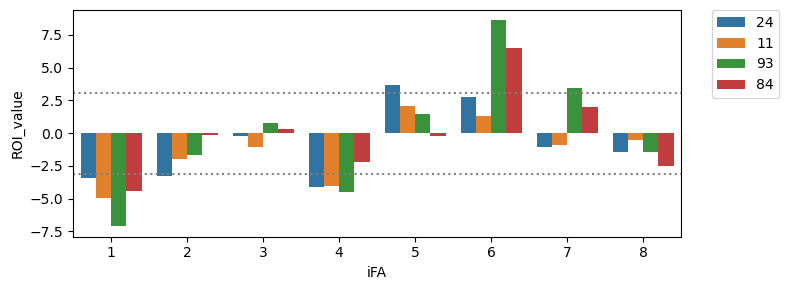

In [35]:

# Assuming you have a figure and axes already created
fig, ax = plt.subplots(figsize=(8,3))  # or use your existing axes

# Your plotting code
df_plot = df_results.loc[df_results['ROI_idx'].isin([24,11,93,84])].copy()
df_plot['ROI_idx'] = df_plot['ROI_idx'].astype(int).astype(str)
sns.barplot(data=df_plot, x='iFA', y='ROI_value', ax=ax, hue='ROI_idx', hue_order=['24','11','93','84'])

# Move the legend outside to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
ax.axhline(y=z_thresh,color = 'grey',linestyle=':')
ax.axhline(y=z_thresh*-1,color = 'grey',linestyle=':')
# Adjust the figure to make room for the legend
plt.tight_layout()

plt.show()# df_plot

In [25]:
# STG
df_conjunction.loc[df_conjunction['ROI_idx'].isin([60,61])]

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
39,61.0,3,168,1- 6- 8+,61.0,A5,Auditory_5_Complex,Auditory_Association
38,60.0,1,1,1-,60.0,A4,Auditory_4_Complex,Auditory_Association


In [26]:
# Positive correlation
df_conjunction.loc[df_conjunction['FA'].str.contains("1")].loc[~df_conjunction['flag'].str.contains("1-")]

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
179,277.0,4,1248,1+ 2- 4+ 8-,277.0,STV,Superior_Temporal_Visual_Area,TPO
185,305.0,4,1257,1+ 2+ 5- 7+,305.0,7 m,Area_7m,Posterior_Cingulate
90,130.0,3,138,1+ 3+ 8+,130.0,POS2,Parieto-Occipital_Sulcus_Area_2,Posterior_Cingulate
191,312.0,3,125,1+ 2+ 5-,312.0,RSC,RetroSplenial_Complex,Posterior_Cingulate
190,310.0,3,128,1+ 2+ 8+,310.0,POS2,Parieto-Occipital_Sulcus_Area_2,Posterior_Cingulate
53,79.0,3,126,1+ 2- 6+,79.0,PoI2,Posterior_Insular_Area_2,Insula_FrontalOperc
136,217.0,3,168,1+ 6+ 8-,217.0,5mv,Area_5m_ventral,ParaCentral_MidCing
163,259.0,2,16,1+ 6+,259.0,PoI2,Posterior_Insular_Area_2,Insula_FrontalOperc
199,325.0,2,16,1+ 6+,325.0,p24pr,Area_Posterior_24_prime,AntCing_MedPFC
157,250.0,1,1,1+,250.0,FOP2,Frontal_Opercular_Area_2,Insula_FrontalOperc


#### FA2

In [15]:
# IFG/IFS/IFJ
# IFS/IFJ is semantic, IFG Tri
df_conjunction.loc[df_conjunction['FA'].str.contains('2')].loc[df_conjunction['Cortical Division']=='Inferior_Frontal'].sort_values(['ROI_idx'])

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
96,159.0,1,2,2-,159.0,44,Area_44,Inferior_Frontal
97,160.0,3,236,2- 3- 6-,160.0,45,Area_45,Inferior_Frontal
99,162.0,1,2,2-,162.0,a47r,Area_anterior_47r,Inferior_Frontal
188,339.0,3,245,2- 4+ 5+,339.0,44,Area_44,Inferior_Frontal
189,340.0,4,2346,2- 3- 4+ 6-,340.0,45,Area_45,Inferior_Frontal
190,341.0,1,2,2-,341.0,47 l,Area_47l_(47_lateral),Inferior_Frontal
193,345.0,3,246,2- 4+ 6+,345.0,IFSa,Area_IFSa,Inferior_Frontal
195,347.0,1,2,2-,347.0,p47r,Area_posterior_47r,Inferior_Frontal


In [28]:
# SMG/AG
df_conjunction.loc[df_conjunction['FA'].str.contains('2')].loc[df_conjunction['Cortical Division']=='Inferior_Parietal']

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
76,114.0,2,26,2- 6+,114.0,PF,Area_PF_Complex,Inferior_Parietal
77,115.0,1,2,2-,115.0,PFm,Area_PFm_Complex,Inferior_Parietal


In [32]:
df_conjunction['Cortical Division'].unique()

array(['Auditory_Association', 'TPO', 'Inferior_Frontal',
       'Lateral_Temporal', 'MT + _Complex', nan, 'Posterior_Cingulate',
       'Dorsolateral_Prefrontal', 'OrbPolaFrontal', 'Early_Auditory',
       'Insula_FrontalOperc', 'ParaCentral_MidCing', 'Medial_Temporal',
       'Superior_Parietal', 'Inferior_Parietal', 'AntCing_MedPFC',
       'Premotor', 'Ventral_Stream_Visual', 'Posterior_Opercular',
       'Dorsal_Stream_Visual', 'Early_Visual', 'SomaSens_Motor'],
      dtype=object)

In [44]:
# STG/STS association
df_conjunction.loc[df_conjunction['Cortical Division'].str.contains('Auditory')].sort_values(['ROI_idx'])

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
33,53.0,1,2,2-,53.0,52,Area_52,Early_Auditory
34,58.0,1,2,2-,58.0,PFcm,Area_PFcm,Early_Auditory
35,60.0,1,1,1-,60.0,A4,Auditory_4_Complex,Auditory_Association
36,61.0,2,16,1- 6-,61.0,A5,Auditory_5_Complex,Auditory_Association
37,62.0,3,368,3- 6- 8+,62.0,STGa,Area_STGa,Auditory_Association
38,63.0,2,36,3- 6-,63.0,STSda,Area_STSd_anterior,Auditory_Association
39,64.0,2,36,3- 6-,64.0,STSdp,Area_STSd_posterior,Auditory_Association
40,66.0,2,36,3- 6-,66.0,STSvp,Area_STSv_posterior,Auditory_Association
41,67.0,2,28,2- 8+,67.0,TA2,Area_TA2,Auditory_Association
132,233.0,1,2,2-,233.0,52,Area_52,Early_Auditory


In [51]:
df_conjunction['Cortical Division'].str.contains('|'.join(['Auditory','Inferior_Frontal','Inferior_Parietal']))

139     True
136     True
165    False
137     True
189     True
       ...  
88     False
89     False
91     False
92     False
78      True
Name: Cortical Division, Length: 206, dtype: bool

In [56]:
# STG/STS association
df_conjunction.loc[~df_conjunction['Cortical Division'].str.contains('|'.join(['Auditory','Inferior_Frontal','Inferior_Parietal']))].sort_values('Cortical Division')

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
92,145.0,1,6,6+,145.0,p24pr,Area_Posterior_24_prime,AntCing_MedPFC
180,315.0,1,8,8+,315.0,10v,Area_10v,AntCing_MedPFC
183,319.0,1,3,3-,319.0,9 m,Area_9_Middle,AntCing_MedPFC
89,137.0,1,6,6+,137.0,33pr,Area_33_prime,AntCing_MedPFC
88,135.0,1,8,8+,135.0,10v,Area_10v,AntCing_MedPFC
...,...,...,...,...,...,...,...,...
69,100.0,1,6,6+,100.0,TPOJ3,Area_TemporoParietoOccipital_Junction_3,TPO
6,13.0,1,6,6-,13.0,V8,Eighth_Visual_Area,Ventral_Stream_Visual
4,11.0,2,14,1- 4-,11.0,FFC,Fusiform_Face_Complex,Ventral_Stream_Visual
7,16.0,1,6,6-,16.0,VMV3,VentroMedial_Visual_Area_3,Ventral_Stream_Visual


In [29]:
# STG
df_conjunction.loc[df_conjunction['FA'].str.contains('2')].loc[df_conjunction['Cortical Division']=='Auditory_Association']

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
139,244.0,6,234678,2- 3- 4+ 6- 7+ 8+,244.0,STSdp,Area_STSd_posterior,Auditory_Association
136,241.0,6,234678,2- 3- 4+ 6- 7+ 8+,241.0,A5,Auditory_5_Complex,Auditory_Association
137,242.0,5,23468,2- 3- 4+ 6- 8+,242.0,STGa,Area_STGa,Auditory_Association
135,240.0,4,2468,2- 4+ 6- 8+,240.0,A4,Auditory_4_Complex,Auditory_Association
141,246.0,4,2367,2- 3- 6- 7+,246.0,STSvp,Area_STSv_posterior,Auditory_Association
41,67.0,2,28,2- 8+,67.0,TA2,Area_TA2,Auditory_Association


In [27]:
df_conjunction.loc[df_conjunction['RegionLongName'].isin(['Area_44','Ventral_Area_6'])]

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
188,339.0,3,245,2- 4+ 5+,339.0,44,Area_44,Inferior_Frontal
30,45.0,1,6,6+,45.0,6v,Ventral_Area_6,Premotor
96,159.0,1,2,2-,159.0,44,Area_44,Inferior_Frontal


In [37]:
df_conjunction.loc[df_conjunction['n']>=4]

,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division
136,241.0,6,234678,2- 3- 4+ 6- 7+ 8+,241.0,A5,Auditory_5_Complex,Auditory_Association
139,244.0,6,234678,2- 3- 4+ 6- 7+ 8+,244.0,STSdp,Area_STSd_posterior,Auditory_Association
137,242.0,5,23468,2- 3- 4+ 6- 8+,242.0,STGa,Area_STGa,Auditory_Association
165,277.0,5,12468,1+ 2- 4+ 6+ 8-,277.0,STV,Superior_Temporal_Visual_Area,TPO
203,387.0,4,2367,2- 3- 6+ 7+,387.0,Amyg,Amygdala,NaN
141,246.0,4,2367,2- 3- 6- 7+,246.0,STSvp,Area_STSv_posterior,Auditory_Association
135,240.0,4,2468,2- 4+ 6- 8+,240.0,A4,Auditory_4_Complex,Auditory_Association
171,305.0,4,1257,1+ 2+ 5- 7+,305.0,7 m,Area_7m,Posterior_Cingulate
13,24.0,4,1245,1- 2- 4- 5+,24.0,PH,Area_PH,MT + _Complex
189,340.0,4,2346,2- 3- 4+ 6-,340.0,45,Area_45,Inferior_Frontal


### Export images

### by factor

In [48]:
for iFA in range(1,9):
    file_FA = os.path.join(Dir_results_2nd,folder,f"FA{iFA}+orig.BRIK.gz")
    if '.nii' in file_FA:
        img_FA = image.load_img(file_FA)
    else:
        img_FA = image.index_img(file_FA, 1) 

    data_FA = img_FA.get_fdata()
    if iFA == 7:
        data_FA = data_FA*-1

    # ROI_idx-map
    data_output = data_atlas.copy()

    # mask the significant voxels with FDR correction
    df = df_results.loc[df_results['iFA']==iFA].loc[df_results['ROI_idx']!=0].copy()
    df = df.loc[df['significant_FDR']==1]
    mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)

    data_output[mask] = 0
    data_FA[mask] = 0

    # # export the image with ROI labels
    for sign,value in zip(['+','-'],[1,-1]):
        df_tmp = df.loc[df['label_FDR']==sign]
        mask = np.isin(data_output, list(df_tmp['ROI_idx'].unique()))

        data_output[mask] = data_output[mask]*value
    #     data_FA[mask] = data_FA[mask]

    new_img = image.new_img_like(img_atlas, data_output)
    output_path = os.path.join(Dir_output, f"FA{iFA}_ROIlabels_FDR.nii.gz")
    new_img.to_filename(output_path)

    new_img = image.new_img_like(img_atlas, data_FA)
    output_path = os.path.join(Dir_output, f"FA{iFA}_zmap_FDR.nii.gz")
    new_img.to_filename(output_path)
#     np.unique(data_output)

In [49]:
output_path

'/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/FactorAnalysis/models/Nvar113NFA8_LPAC_multipleReg_unsmoothed/FA8_HCPex/results/secondlevel/threshold_p005FDR/conjunction/gradiant/FA8_zmap_FDR.nii.gz'

In [15]:
Dir_results_2nd

'/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/FactorAnalysis/models/Nvar113NFA8_LPAC_multipleReg/FA8_HCPex/results/secondlevel'

### grouping >3 or <=2

In [20]:
# Suppress all user warnings
warnings.filterwarnings("ignore", category=UserWarning)
# fsaverage = datasets.fetch_surf_fsaverage()

Dir_output = os.path.join(Dir_results_2nd,'threshold_p001','conjunction','gradiant')

# all over 3
df = df_conjunction.loc[df_conjunction['n']>=3]
data_output = data_atlas.copy()

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_allover3_ROIlabels_001.nii.gz")
new_img.to_filename(output_path)

for number in df['n'].unique():
    df_tmp = df_conjunction.loc[df_conjunction['n']==number]
    df_tmp = df_tmp.loc[df_tmp['ROI_idx']!=0]
    mask = np.isin(data_atlas, list(df_tmp['ROI_idx'].unique()))
    data_output[mask] = number

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

# export
new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_allover3_001.nii.gz")
new_img.to_filename(output_path)



# title = f"FA{NFA}_allover4"
# compile_plots(new_img,Dir_output,title)

In [19]:
# <=3
df = df_conjunction.loc[df_conjunction['n']<3]
data_output = data_atlas.copy()

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_less3_ROIlabels_001.nii.gz")
new_img.to_filename(output_path)

for number in df['n'].unique():
    df_tmp = df_conjunction.loc[df_conjunction['n']==number]
    df_tmp = df_tmp.loc[df_tmp['ROI_idx']!=0]
    mask = np.isin(data_atlas, list(df_tmp['ROI_idx'].unique()))
    data_output[mask] = number

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

# export
new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_less3_001.nii.gz")
new_img.to_filename(output_path)


# title = f"FA{NFA}_allover4"
# compile_plots(new_img,Dir_output,title)

### grouping >4 or <=3

In [68]:
# Suppress all user warnings
warnings.filterwarnings("ignore", category=UserWarning)
# fsaverage = datasets.fetch_surf_fsaverage()

Dir_output = os.path.join(Dir_results_2nd,'threshold_p005','conjunction','gradiant')

# all over 4
df = df_conjunction.loc[df_conjunction['n']>=4]
data_output = data_atlas.copy()

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_allover4_ROIlabels_FDR.nii.gz")
new_img.to_filename(output_path)

for number in df['n'].unique():
    df_tmp = df_conjunction.loc[df_conjunction['n']==number]
    df_tmp = df_tmp.loc[df_tmp['ROI_idx']!=0]
    mask = np.isin(data_atlas, list(df_tmp['ROI_idx'].unique()))
    data_output[mask] = number

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

# export
new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_allover4_FDR.nii.gz")
new_img.to_filename(output_path)



# title = f"FA{NFA}_allover4"
# compile_plots(new_img,Dir_output,title)

In [69]:
# <=3
df = df_conjunction.loc[df_conjunction['n']<4]
data_output = data_atlas.copy()

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_less4_ROIlabels_FDR.nii.gz")
new_img.to_filename(output_path)

for number in df['n'].unique():
    df_tmp = df_conjunction.loc[df_conjunction['n']==number]
    df_tmp = df_tmp.loc[df_tmp['ROI_idx']!=0]
    mask = np.isin(data_atlas, list(df_tmp['ROI_idx'].unique()))
    data_output[mask] = number

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

# export
new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_less4_FDR.nii.gz")
new_img.to_filename(output_path)


# title = f"FA{NFA}_allover4"
# compile_plots(new_img,Dir_output,title)

### by function: S, PO, PSO, Executive

In [44]:
rule = 'rule8'
Dir_output = os.path.join(Dir_results_2nd,'threshold_p005','conjunction','aggregate',rule)
if not os.path.exists(Dir_output):
    os.makedirs(Dir_output)

label = 'Sem'
List_rules = ['6', '7', '8', '67', '78', '68']
###
df = df_conjunction[
    df_conjunction['FA'].isin(List_rules)
]

data_output = data_atlas.copy()

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_{label}_ROIlabels_FDR.nii.gz")
new_img.to_filename(output_path)

for number in df['n'].unique():
    df_tmp = df_conjunction.loc[df_conjunction['n']==number]
    df_tmp = df_tmp.loc[df_tmp['ROI_idx']!=0]
    mask = np.isin(data_atlas, list(df_tmp['ROI_idx'].unique()))
    data_output[mask] = number

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

# export
new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_{label}_FDR.nii.gz")
new_img.to_filename(output_path)


In [43]:
print(Dir_output)

/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/FactorAnalysis/models/Nvar113NFA8_LPAC_multipleReg/FA8_HCPex/results/secondlevel/threshold_p005/conjunction/gradiant/rule8


# Delete

In [39]:
# semantic
FAs = [1,6,7,8]
df = df_results.loc[df_results['iFA'].isin(FAs)]
df_values = df.pivot(index='ROI_idx',columns='iFA',values='ROI_value')
df_sig = df.pivot(index='ROI_idx',columns='iFA',values='significant')

df_selected = df_values.loc[(df_values[6].abs()>0)|(df_values[7].abs()>0)|(df_values[8].abs()>0)]
df_selected = df_selected.loc[df_selected[1]>0]
# df_selected = df_selected.loc[df_sig.all(axis=1)]
df_selected = df_selected.loc[(df_sig[6]==1)|(df_sig[7]>0)|(df_sig[8]>0)]
df_selected = df_selected.loc[df_sig[1]>0]
df_selected1 = df_selected.copy()
df_selected

iFA,1,6,7,8
ROI_idx,,,,
37.0,2.615037,7.024399,0.285055,-3.247420
49.0,4.156101,3.062344,0.196178,1.337487
78.0,2.665458,5.128762,1.253271,-0.183081
79.0,3.788240,7.597638,0.007128,-1.940807
89.0,2.737537,-3.617093,-1.182537,1.101575
130.0,3.632252,-0.645347,2.170446,3.930502
212.0,2.760498,4.621778,-1.487728,-4.136535
217.0,3.545913,5.259818,-2.718400,-3.357020
228.0,3.441171,1.049533,-2.825368,-0.497767


In [40]:
# OSP
FAs = [1,3,4]
df = df_results.loc[df_results['iFA'].isin(FAs)]
df_values = df.pivot(index='ROI_idx',columns='iFA',values='ROI_value')
df_sig = df.pivot(index='ROI_idx',columns='iFA',values='significant')

df_selected = df_values.loc[(df_values[1]>0)&((df_values[3]<0)|(df_values[4]<0))]
df_selected = df_selected.loc[(df_sig[1]==1)&((df_sig[3]>0)|(df_sig[4]>0))]
# df_selected = df_selected.loc[df_sig.all(axis=1)]
df_selected2 = df_selected.copy()
df_selected

iFA,1,3,4
ROI_idx,,,
89.0,2.737537,-3.287945,0.226901
130.0,3.632252,3.187155,-1.259482
277.0,3.493377,-2.832208,3.996364
310.0,5.183464,2.931950,-0.795859


In [41]:
# O-P
FAs = [2,5,3,4]
df = df_results.loc[df_results['iFA'].isin(FAs)]
df_values = df.pivot(index='ROI_idx',columns='iFA',values='ROI_value')
df_sig = df.pivot(index='ROI_idx',columns='iFA',values='significant')

# df_selected = df_values.loc[df_values[2].abs()>0].loc[df_values[5].abs()>0]
# df_selected = df_values.loc[df_sig.all(axis=1)]
df_selected = df_values.loc[(df_values[2]>0)&(df_values[5].abs()>0)&((df_values[3]>0)|(df_values[4]>0))]

df_selected = df_selected.loc[(df_sig[2]==1)&(df_sig[5]==1)&((df_sig[3]>0)|(df_sig[4]>0))]

df_selected3 = df_selected.copy()
df_selected


iFA,2,3,4,5
ROI_idx,,,,
125.0,3.422360,1.136525,-3.647942,-3.136579
310.0,3.515748,2.931950,-0.795859,-2.672246


In [42]:
# general
FAs = [1,2,3,4,6,7,8]
df = df_results.loc[df_results['iFA'].isin(FAs)]
df_values = df.pivot(index='ROI_idx',columns='iFA',values='ROI_value')
df_sig = df.pivot(index='ROI_idx',columns='iFA',values='significant')

# df_selected = df_values.loc[(df_values[6].abs()>0)&((df_values[7].abs()>0)|(df_values[8].abs()>0))]
df_selected = df_values.copy()
# df_selected = df_values.loc[(df_values[1]<0)&((df_values[3]>0)|(df_values[4]>0))]
df_selected = df_selected.loc[(df_selected[1]<0)&((df_selected[4]<0)|(df_selected[3]<0))]
# df_selected = df_selected.loc[df_sig.all(axis=1)]
df_selected = df_selected.loc[(df_sig[1]>0)&((df_sig[4]>0)|(df_sig[3]>0))]
df_selected4 = df_selected.copy()
df_selected

iFA,1,2,3,4,6,7,8
ROI_idx,,,,,,,
11.0,-4.948197,-1.949104,-1.034829,-4.014823,1.296638,-0.872750,-0.546973
24.0,-3.389364,-3.279340,-0.248059,-4.145150,2.777956,-1.024380,-1.474684
61.0,-4.917449,1.395346,-2.608785,0.017142,-5.583539,2.433416,3.114660
93.0,-7.115066,-1.698896,0.781373,-4.500855,8.603520,3.444065,-1.455458
96.0,-2.682492,-6.021473,-4.458526,3.285135,-0.179230,5.768172,0.319883
98.0,-3.362147,-1.836933,-3.618982,1.984518,-1.056368,3.097116,-0.408071
111.0,-2.906990,-0.873369,0.918356,-2.790160,1.057946,-1.624919,0.279337
167.0,-3.771201,-3.114514,-3.143207,1.443600,2.800448,0.439841,-0.016960
241.0,-3.067077,-4.830541,-3.535040,4.873097,-8.639080,4.592682,3.563237


In [43]:
df_agg = []
for i,df in enumerate([df_selected1,df_selected2,df_selected3,df_selected4]):
    df_agg.append(pd.DataFrame({'#No.':df.index,'label':i+1,'value':str(i+1)}))
df_agg = pd.concat(df_agg,ignore_index=True)
# pd.DataFrame({'#No.':df.index,'label':i})
# df_agg['value']=1
df_agg_plot = df_agg.pivot(index='#No.',columns='label',values='value')
for i, row in df_agg_plot.iterrows():
    df_agg_plot.loc[i,'idx_plot'] = ''.join(row.dropna().values)
df_agg_plot


/tmp/ipykernel_133995/2381138316.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '4' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_agg_plot.loc[i,'idx_plot'] = ''.join(row.dropna().values)


label,1,2,3,4,idx_plot
#No.,,,,,
11.0,NaN,NaN,NaN,4,4
24.0,NaN,NaN,NaN,4,4
37.0,1,NaN,NaN,NaN,1
49.0,1,NaN,NaN,NaN,1
61.0,NaN,NaN,NaN,4,4
78.0,1,NaN,NaN,NaN,1
79.0,1,NaN,NaN,NaN,1
89.0,1,2,NaN,NaN,12
93.0,NaN,NaN,NaN,4,4


In [44]:
for idx_plot in df_agg_plot['idx_plot'].unique():
    df = df_agg_plot.loc[df_agg_plot['idx_plot']==idx_plot]
df

label,1,2,3,4,idx_plot
#No.,,,,,
310.0,1,2,3,NaN,123


# Write image

In [45]:
Dir_output = os.path.join(Dir_results_2nd,'threshold_p005','conjunction','aggregate')
if not os.path.exists(Dir_output):
    os.makedirs(Dir_output)
    
for i,df,label in zip(range(4),[df_selected1,df_selected2,df_selected3,df_selected4],['Sem','OSP','form','general',]):
    
    # ROI labels
    data_output = data_atlas.copy()
    mask = np.isin(data_atlas, df.index,invert=True)
    data_output[mask] = 0

    new_img = image.new_img_like(img_atlas, data_output)
    output_path = os.path.join(Dir_output, f"image_aggregate_g{i+1}_{label}_ROIlabels.nii.gz")
    new_img.to_filename(output_path)
    
    # binary
    data_output = data_atlas.copy()
    mask = np.isin(data_atlas, df.index,invert=True)
    data_output[mask] = 0
    data_output[data_output>0] = 1

    new_img = image.new_img_like(img_atlas, data_output)
    output_path = os.path.join(Dir_output, f"image_aggregate_g{i+1}_{label}_binary.nii.gz")
    new_img.to_filename(output_path)

In [46]:

data_output = data_atlas.copy()
mask = np.isin(data_atlas, df_agg_plot.index,invert=True)
data_output[mask] = 0
data_output_ROI = data_output.copy()




for new_idx,idx_plot in enumerate(df_agg_plot['idx_plot'].unique()):
    
    df = df_agg_plot.loc[df_agg_plot['idx_plot']==idx_plot]
    
    mask = np.isin(data_atlas, df.index,invert=True)
    data_tmp = data_output.copy()
    data_tmp[mask] = 0
    data_output[data_tmp>0] = new_idx+1
    data_output_ROI[data_tmp>0] = idx_plot
    
new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"image_aggregate.nii.gz")
new_img.to_filename(output_path)

new_img = image.new_img_like(img_atlas, data_output_ROI)
output_path = os.path.join(Dir_output, f"image_aggregate_ROIlabels.nii.gz")
new_img.to_filename(output_path)

In [47]:
df_color = pd.DataFrame({'idx_plot':df_agg_plot['idx_plot'].unique()})
df_color['new_idx'] = range(1,df_color.shape[0]+1)
for idx_plot,color,label in zip(range(1,4+1),['red','yellow','green','blue',],['semantic','OSP','form','general',]):
    df_color.loc[df_color['idx_plot']==str(idx_plot),'color'] = color
    df_color.loc[df_color['idx_plot']==str(idx_plot),'label'] = label

# df_color.loc[df_color['idx_plot']=='1','color'] = 'green' # form
# df_color.loc[df_color['idx_plot']=='2','color'] = 'yellow' # OSP
# df_color.loc[df_color['idx_plot']=='3','color'] = 'blue' # general
# df_color.loc[df_color['idx_plot']=='4','color'] = 'red' # semantic
# df_color.loc[df_color['idx_plot']=='34','color'] = 'purple' # 
# df_color.sort_values('idx_plot')
df_color

/tmp/ipykernel_133995/489402379.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'red' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_color.loc[df_color['idx_plot']==str(idx_plot),'color'] = color
/tmp/ipykernel_133995/489402379.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'semantic' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_color.loc[df_color['idx_plot']==str(idx_plot),'label'] = label


,idx_plot,new_idx,color,label
0,4,1,blue,general
1,1,2,red,semantic
2,12,3,NaN,NaN
3,3,4,green,form
4,123,5,NaN,NaN


# delete

In [ ]:
"Red": np.array([230, 57, 70]) / 255,   # #E63946
"Blue": np.array([69, 123, 157]) / 255, # #457B9D
"Green": np.array([42, 157, 143]) / 255, # #2A9D8F
"Yellow": np.array([244, 162, 97]) / 255 # #F4A261

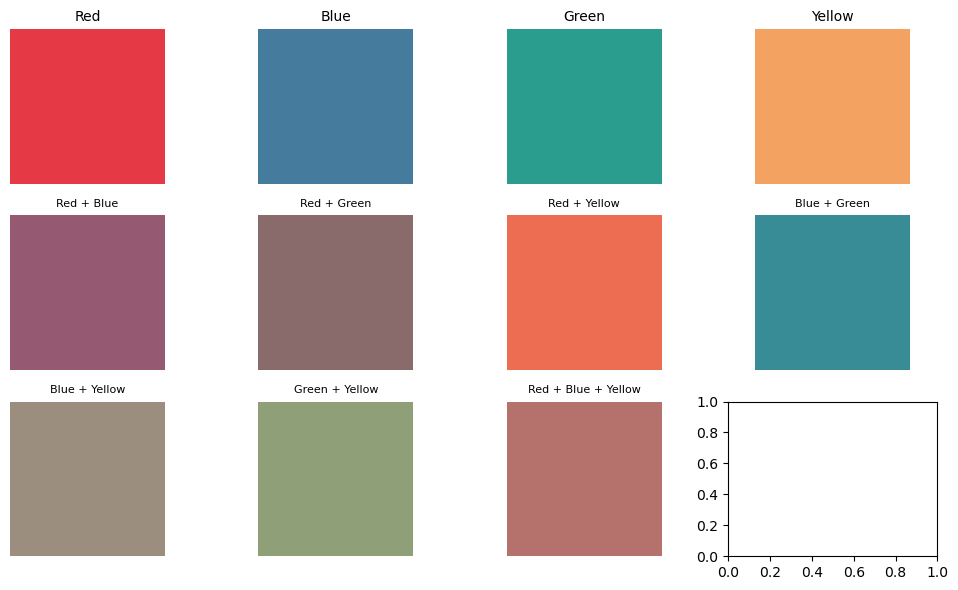

In [146]:
import numpy as np
import matplotlib.pyplot as plt

# Define four distinct base colors in RGB (normalized 0-1)
colors = {
    "Red": np.array([230, 57, 70]) / 255,   # #E63946
    "Blue": np.array([69, 123, 157]) / 255, # #457B9D
    "Green": np.array([42, 157, 143]) / 255, # #2A9D8F
    "Yellow": np.array([244, 162, 97]) / 255 # #F4A261
}

# Function to mix colors (simple average)
def mix_colors(*cols):
    return np.mean(cols, axis=0)

# Generate mixed colors
mixed_colors = {
    "Red + Blue": mix_colors(colors["Red"], colors["Blue"]),
    "Red + Green": mix_colors(colors["Red"], colors["Green"]),
    "Red + Yellow": mix_colors(colors["Red"], colors["Yellow"]),
    "Blue + Green": mix_colors(colors["Blue"], colors["Green"]),
    "Blue + Yellow": mix_colors(colors["Blue"], colors["Yellow"]),
    "Green + Yellow": mix_colors(colors["Green"], colors["Yellow"]),
    "Red + Blue + Yellow": mix_colors(colors["Red"], colors["Blue"], colors["Yellow"])
}

# Adjust grid size: 1 row for base colors, 2 rows for mixed colors
fig, axes = plt.subplots(3, 4, figsize=(10, 6))

# Plot base colors (row 0)
for i, (name, color) in enumerate(colors.items()):
    axes[0, i].imshow([[color]])
    axes[0, i].set_title(name, fontsize=10)
    axes[0, i].axis("off")

# Plot mixed colors (rows 1 and 2)
mixed_names = list(mixed_colors.keys())
for i, (name, color) in enumerate(mixed_colors.items()):
    row, col = divmod(i, 4)  # Arrange in 2 rows, 4 columns max
    axes[row + 1, col].imshow([[color]])
    axes[row + 1, col].set_title(name, fontsize=8)
    axes[row + 1, col].axis("off")

# Hide empty subplots
for i in range(len(mixed_colors), 8):  # We have 4+7=11 colors but 12 slots (3x4)
    axes.flatten()[i].axis("off")

plt.tight_layout()
plt.show()


In [211]:
df.loc[df['idx'].isin([1,2,3])][[x for x in df.columns if 'Col' in x]]

,Col1,Col2,Col3,Col4,Col5,Col6
0,0.004556,0.009785,0.008659,0.000230,0.006930,0.009133
1,0.002250,0.007923,0.007998,0.001361,0.007126,0.006871
2,0.005558,0.007945,0.007247,0.003069,0.000569,0.000122


In [82]:
Dir_output = os.path.join(Dir_results_2nd,'threshold_p005','conjunction','aggregate')
if not os.path.exists(Dir_output):
    os.makedirs(Dir_output)
    
for i,df,label in zip(range(4),[df_selected1,df_selected2,df_selected3,df_selected4],['form','OSP','general','Sem']):
    
    # ROI labels
    data_output = data_atlas.copy()
    mask = np.isin(data_atlas, df.index,invert=True)
    data_output[mask] = 0

    new_img = image.new_img_like(img_atlas, data_output)
    output_path = os.path.join(Dir_output, f"image_aggregate_g{i+1}_{label}_ROIlabels.nii.gz")
    new_img.to_filename(output_path)
    
    # binary
    data_output = data_atlas.copy()
    mask = np.isin(data_atlas, df.index,invert=True)
    data_output[mask] = 0
    data_output[data_output>0] = 1

    new_img = image.new_img_like(img_atlas, data_output)
    output_path = os.path.join(Dir_output, f"image_aggregate_g{i+1}_{label}_binary.nii.gz")
    new_img.to_filename(output_path)

In [61]:
Dir_output


'/work/desai-lab/xuanyang/Project/Semantic/analysis/ParametricModulation/Nastase/allstories/FactorAnalysis/models/Nvar113NFA8_LPAC_multipleReg/FA8_HCPex/results/secondlevel/threshold_p005/conjunction/aggregate'

In [12]:
df = df_results.loc[df_results['iFA'].isin(FAs)]
df

,iFA,ROI_idx,ROI_value,significant,alpha,label
2030,6,0.0,2.869079,1,0.005,+
2031,6,1.0,0.459331,0,0.005,
2032,6,2.0,-0.020992,0,0.005,
2033,6,3.0,-2.245012,0,0.005,
2034,6,4.0,-3.656724,1,0.005,-
...,...,...,...,...,...,...
3243,8,417.0,0.940276,0,0.005,
3244,8,420.0,2.619962,1,0.005,+
3245,8,424.0,2.498798,0,0.005,
3246,8,425.0,0.463374,0,0.005,


In [15]:
df.pivot(index='ROI_idx',columns='iFA',values='significant').all(axis=1)

ROI_idx
0.0      False
1.0      False
2.0      False
3.0      False
4.0      False
         ...  
417.0    False
420.0     True
424.0    False
425.0    False
426.0    False
Length: 406, dtype: bool

In [16]:
df.pivot(index='ROI_idx',columns='iFA',values='significant')

iFA,6,7,8
ROI_idx,,,
0.0,1,0,0
1.0,0,0,0
2.0,0,0,0
3.0,0,0,0
4.0,1,0,0
...,...,...,...
417.0,0,0,0
420.0,1,1,1
424.0,0,0,0


In [53]:
df_results.loc[df_results['ROI_idx']==420]

,iFA,ROI_idx,ROI_value,significant,alpha,label
402,1,420.0,-1.030900,0,0.005,
808,2,420.0,-1.856393,0,0.005,
1214,3,420.0,-3.883697,1,0.005,-
1620,4,420.0,2.174852,0,0.005,
2026,5,420.0,0.568195,0,0.005,
2432,6,420.0,3.188880,1,0.005,+
2838,7,420.0,3.106874,1,0.005,+
3244,8,420.0,2.619962,1,0.005,+


In [7]:
df_target = df_results.loc[df_results['ROI_idx']==277].copy()
# ' '.join(df_target.loc[df_target['label']!='','label'])
df_target = df_target.loc[df_target['label']!='']
flag = ' '.join(df_target['iFA'].astype(str)+df_target['label'])
print(flag)
df_results.loc[df_results['ROI_idx']==277]

1+ 2- 3- 4+ 6+ 7+ 8-


,iFA,ROI_idx,ROI_value,significant,alpha,label
277,1,277.0,3.493377,1,0.005,+
683,2,277.0,-5.308212,1,0.005,-
1089,3,277.0,-2.832208,1,0.005,-
1495,4,277.0,3.996364,1,0.005,+
1901,5,277.0,-1.207936,0,0.005,
2307,6,277.0,3.073129,1,0.005,+
2713,7,277.0,2.840149,1,0.005,+
3119,8,277.0,-3.769976,1,0.005,-


In [9]:
df_atlas.loc[df_atlas['#No.']==340]

,#No.,Label,Name:,R,G,B
340,340,Area_45_R,199,123,202,0


In [10]:
def plot_surface(img,file_output,hemi,view,):
    if hemi == 'R':
        mesh = surface.load_surf_mesh(fsaverage.pial_right)
        bg_map = fsaverage.sulc_right
        hemi = 'right'
    else:
        mesh = surface.load_surf_mesh(fsaverage.pial_left)
        bg_map = fsaverage.sulc_left
        hemi = 'left'
        
    stat_map = surface.vol_to_surf(img, mesh)
    stat_map[stat_map>0.01] = 1
    
    th=0.2
#     if stat_map[stat_map!=0].shape[0] == 0:
#         th=0

    # Generate the Plotly figure
    fig = plotting.plot_surf(
        surf_mesh=mesh, surf_map=stat_map, bg_map=bg_map, hemi=hemi, view=view, 
        engine='plotly', cmap='coolwarm', symmetric_cmap=False, colorbar=False, 
    #     avg_method=None, 
        threshold=th, alpha=None, bg_on_data=False, #darkness=0.7, 
        vmin=-1, vmax=1, 
        cbar_vmin=None, cbar_vmax=None, 
        cbar_tick_format='auto', title=None, title_font_size=18, output_file=None, axes=None, figure=None)

    pio.write_image(fig.figure, file_output, format="jpg")

def compile_plots(img,Dir_output,title):
    
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 8),gridspec_kw={'height_ratios': [2, 1.5,1.5]})
    axes_flat = axes.flatten()

    for idx, ax in enumerate(axes_flat):
        hemi,view = df_views.loc[idx]

        file_output = os.path.join(Dir_output,f'tmp_{hemi}_{view}.jpg')
        plot_surface(img,file_output,hemi = hemi,view=view)

        img_jpg = mpimg.imread(file_output)
        if (hemi=='L') & (view == 'ventral'):
            img_jpg = np.flipud(img_jpg)
            img_jpg = np.fliplr(img_jpg)
        ax.imshow(img_jpg)
        ax.set_xticks([])  
        ax.set_yticks([])  
        ax.set_xlabel('')  
        ax.set_ylabel('')  
        ax.axis('off')  
    plt.suptitle(title)
    plt.tight_layout()
#     plt.show()
    plt.close()
#     file_output = filename.replace('img','fig').replace('.nii','.jpg')
    file_output = f"fig_conjunction_{title}.jpg"
    fig.savefig(os.path.join(Dir_output,file_output))

# Conjunction

In [11]:
df_views = []
for view in ['lateral','medial','ventral']:
    for hemi in ['L','R']:
    
        df_views.append(pd.DataFrame({'hemi':hemi,'view':view},index=[0]))
df_views = pd.concat(df_views,ignore_index=True)


In [36]:
df_results_wide = df_results.pivot(index='ROI_idx',columns=['iFA'],values='significant')
List_FAs = [2,3,4,6,7,8]
overlap = ''.join([str(x) for x in List_FAs])
vector = df_results_wide[List_FAs].agg(lambda row: row.all(), axis=1).astype(int)


data_output = np.zeros(data_atlas.shape)
List_survive = vector[vector==1].index.to_list()
mask = np.isin(data_atlas, List_survive)
data_output[mask] = 1

if mask.any():
    # export
    warnings.filterwarnings("ignore", category=UserWarning)
    fsaverage = datasets.fetch_surf_fsaverage()
    
    Dir_output = os.path.join(Dir_results_2nd,'threshold_p005','conjunction','overlap')

    # binary
    new_img = image.new_img_like(img_atlas, data_output)
    output_path = os.path.join(Dir_output, f"FA{NFA}_{len(overlap)}FA{overlap}.nii.gz")
    new_img.to_filename(output_path)

    # surface
    title = f"{len(overlap)}FA{overlap}"
    compile_plots(new_img,Dir_output,title)
    
    # ROI labels
    df_atlas.loc[List_survive].to_csv(os.path.join(Dir_output,f"table_{title}.csv"),index=False)

    # MNI ROI labels
    data_output = data_atlas.copy()
    mask = np.isin(data_atlas, List_survive,invert=True)
    data_output[mask] = 0
    new_img = image.new_img_like(img_atlas, data_output)
    output_path = os.path.join(Dir_output, f"FA{NFA}_{len(overlap)}FA{overlap}_ROIlabels.nii.gz")
    new_img.to_filename(output_path)

# By ROI

In [12]:
df_conjunction = []
for i,roi in enumerate(np.unique(data_atlas)):
    df = df_results.loc[df_results['ROI_idx']==roi]
    df = df.loc[df['label']!='']
    flag = ' '.join(df['iFA'].astype(str)+df['label'])
    # if flag != '':
    if df.shape[0]>0:
        df_conjunction.append(pd.DataFrame({'ROI_idx':roi,'n':df.shape[0],
                                            'FA':''.join(df['iFA'].astype(str)),'flag':flag},index=[0]))
        # print(flag)
df_conjunction = pd.concat(df_conjunction)
df_conjunction = pd.merge(left=df_conjunction,left_on='ROI_idx',right=df_atlas[['#No.','Label']],right_on='#No.',how='left')
df_conjunction.sort_values(['n'],ascending=False,inplace=True)
df_conjunction = df_conjunction.loc[df_conjunction['ROI_idx']!=0]
df_conjunction

,ROI_idx,n,FA,flag,#No.,Label
192,241.0,7,1234678,1- 2- 3- 4+ 6- 7+ 8+,241,Auditory_5_Complex_R
226,277.0,7,1234678,1+ 2- 3- 4+ 6+ 7+ 8-,277,Superior_Temporal_Visual_Area_R
130,160.0,6,235678,2- 3- 5+ 6- 7+ 8+,160,Area_45_L
195,244.0,6,234678,2- 3- 4+ 6- 7+ 8+,244,Area_STSd_posterior_R
193,242.0,5,23468,2- 3- 4+ 6- 8+,242,Area_STGa_R
...,...,...,...,...,...,...
25,34.0,1,6,6+,34,Ventral_Area_24d_L
26,36.0,1,6,6+,36,Area_5m_L
29,39.0,1,6,6+,39,Area_6mp_L
33,43.0,1,2,2-,43,Dorsal_area_6_L


# Plot

In [13]:
def plot_surface(img,file_output,hemi,view,):
    if hemi == 'R':
        mesh = surface.load_surf_mesh(fsaverage.pial_right)
        bg_map = fsaverage.sulc_right
        hemi = 'right'
    else:
        mesh = surface.load_surf_mesh(fsaverage.pial_left)
        bg_map = fsaverage.sulc_left
        hemi = 'left'
        
    stat_map = surface.vol_to_surf(img, mesh)
    stat_map[stat_map>0.01] = 1
    
    th=0.2
#     if stat_map[stat_map!=0].shape[0] == 0:
#         th=0

    # Generate the Plotly figure
    fig = plotting.plot_surf(
        surf_mesh=mesh, surf_map=stat_map, bg_map=bg_map, hemi=hemi, view=view, 
        engine='plotly', cmap='coolwarm', symmetric_cmap=False, colorbar=False, 
    #     avg_method=None, 
        threshold=th, alpha=None, bg_on_data=False, #darkness=0.7, 
        vmin=-1, vmax=1, 
        cbar_vmin=None, cbar_vmax=None, 
        cbar_tick_format='auto', title=None, title_font_size=18, output_file=None, axes=None, figure=None)

    pio.write_image(fig.figure, file_output, format="jpg")

def compile_plots(img,Dir_output,title):
    
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 8),gridspec_kw={'height_ratios': [2, 1.5,1.5]})
    axes_flat = axes.flatten()

    for idx, ax in enumerate(axes_flat):
        hemi,view = df_views.loc[idx]

        file_output = os.path.join(Dir_output,f'tmp_{hemi}_{view}.jpg')
        plot_surface(img,file_output,hemi = hemi,view=view)

        img_jpg = mpimg.imread(file_output)
        if (hemi=='L') & (view == 'ventral'):
            img_jpg = np.flipud(img_jpg)
            img_jpg = np.fliplr(img_jpg)
        ax.imshow(img_jpg)
        ax.set_xticks([])  
        ax.set_yticks([])  
        ax.set_xlabel('')  
        ax.set_ylabel('')  
        ax.axis('off')  
    plt.suptitle(title)
    plt.tight_layout()
#     plt.show()
    plt.close()
#     file_output = filename.replace('img','fig').replace('.nii','.jpg')
    file_output = f"fig_conjunction_{title}.jpg"
    fig.savefig(os.path.join(Dir_output,file_output))

In [14]:
df_conjunction

,ROI_idx,n,FA,flag,#No.,Label
192,241.0,7,1234678,1- 2- 3- 4+ 6- 7+ 8+,241,Auditory_5_Complex_R
226,277.0,7,1234678,1+ 2- 3- 4+ 6+ 7+ 8-,277,Superior_Temporal_Visual_Area_R
130,160.0,6,235678,2- 3- 5+ 6- 7+ 8+,160,Area_45_L
195,244.0,6,234678,2- 3- 4+ 6- 7+ 8+,244,Area_STSd_posterior_R
193,242.0,5,23468,2- 3- 4+ 6- 8+,242,Area_STGa_R
...,...,...,...,...,...,...
25,34.0,1,6,6+,34,Ventral_Area_24d_L
26,36.0,1,6,6+,36,Area_5m_L
29,39.0,1,6,6+,39,Area_6mp_L
33,43.0,1,2,2-,43,Dorsal_area_6_L


In [36]:
# Suppress all user warnings
warnings.filterwarnings("ignore", category=UserWarning)
fsaverage = datasets.fetch_surf_fsaverage()

Dir_output = os.path.join(Dir_results_2nd,'threshold_p005','conjunction','overlap')

for overlap in df_conjunction.loc[df_conjunction['n']>=3]['FA'].unique():
    df_tmp = df_conjunction.loc[df_conjunction['FA']==overlap]
    df_tmp.to_csv(os.path.join(Dir_output,f"FA{NFA}_{len(overlap)}FA{overlap}_ROIlabels.csv"),index=False)

    
    data_output = np.zeros(data_atlas.shape)    
    mask = np.isin(data_atlas, list(df_tmp['ROI_idx'].unique()))
    data_output[mask] = 1
    new_img = image.new_img_like(img_atlas, data_output)
    output_path = os.path.join(Dir_output, f"FA{NFA}_{len(overlap)}FA{overlap}.nii.gz")
    new_img.to_filename(output_path)

    data_output = data_atlas.copy()
    mask = np.isin(data_atlas, list(df_tmp['ROI_idx'].unique()),invert=True)
    data_output[mask] = 0
    new_img = image.new_img_like(img_atlas, data_output)
    output_path = os.path.join(Dir_output, f"FA{NFA}_{len(overlap)}FA{overlap}_ROIlabels.nii.gz")
    new_img.to_filename(output_path)
    
    # title = f"{len(overlap)}FA{overlap}"
    # compile_plots(new_img,Dir_output,title)

In [49]:
df_conjunction.loc[df_conjunction['ROI_idx']==119]

,ROI_idx,n,FA,flag,#No.,Label
102,119.0,1,6,6+,119,Area_PGp_L


# all in one

In [15]:
df_conjunction.loc[df_conjunction['FA'].str.contains('678')]

,ROI_idx,n,FA,flag,#No.,Label
192,241.0,7,1234678,1- 2- 3- 4+ 6- 7+ 8+,241,Auditory_5_Complex_R
226,277.0,7,1234678,1+ 2- 3- 4+ 6+ 7+ 8-,277,Superior_Temporal_Visual_Area_R
130,160.0,6,235678,2- 3- 5+ 6- 7+ 8+,160,Area_45_L
195,244.0,6,234678,2- 3- 4+ 6- 7+ 8+,244,Area_STSd_posterior_R
174,217.0,4,1678,1+ 6+ 7- 8-,217,Area_5m_ventral_R
133,163.0,4,1678,1- 6+ 7+ 8+,163,Area_IFJa_L
301,420.0,4,3678,3- 6+ 7+ 8+,420,Amygdala_R
274,346.0,3,678,6+ 7+ 8+,346,Area_IFSp_R


In [21]:
df_tmp

,ROI_idx,n,FA,flag,#No.,Label
192,241.0,7,1234678,1- 2- 3- 4+ 6- 7+ 8+,241,Auditory_5_Complex_R
226,277.0,7,1234678,1+ 2- 3- 4+ 6+ 7+ 8-,277,Superior_Temporal_Visual_Area_R
130,160.0,6,235678,2- 3- 5+ 6- 7+ 8+,160,Area_45_L
195,244.0,6,234678,2- 3- 4+ 6- 7+ 8+,244,Area_STSd_posterior_R
193,242.0,5,23468,2- 3- 4+ 6- 8+,242,Area_STGa_R
82,96.0,5,12347,1- 2- 3- 4+ 7+,96,PeriSylvian_Language_Area_L
243,305.0,5,12578,1+ 2+ 5- 7+ 8+,305,Area_7m_R
197,246.0,5,23467,2- 3- 4+ 6- 7+,246,Area_STSv_posterior_R
292,387.0,5,12367,1- 2- 3- 6+ 7+,387,Amygdala_L
16,24.0,5,12456,1- 2- 4- 5+ 6+,24,Area_PH_L


In [31]:
# Suppress all user warnings
warnings.filterwarnings("ignore", category=UserWarning)
fsaverage = datasets.fetch_surf_fsaverage()

Dir_output = os.path.join(Dir_results_2nd,'threshold_p005','conjunction','gradiant')

# all over 4
df = df_conjunction.loc[df_conjunction['n']>=4]
data_output = data_atlas.copy()

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_allover4_ROIlabels.nii.gz")
new_img.to_filename(output_path)

for number in df['n'].unique():
    df_tmp = df_conjunction.loc[df_conjunction['n']==number]
    df_tmp = df_tmp.loc[df_tmp['ROI_idx']!=0]
    mask = np.isin(data_atlas, list(df_tmp['ROI_idx'].unique()))
    data_output[mask] = number

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

# export
new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_allover4.nii.gz")
new_img.to_filename(output_path)


# title = f"FA{NFA}_allover4"
# compile_plots(new_img,Dir_output,title)

In [33]:
# <=3
df = df_conjunction.loc[df_conjunction['n']<4]
data_output = data_atlas.copy()

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_less4_ROIlabels.nii.gz")
new_img.to_filename(output_path)

for number in df['n'].unique():
    df_tmp = df_conjunction.loc[df_conjunction['n']==number]
    df_tmp = df_tmp.loc[df_tmp['ROI_idx']!=0]
    mask = np.isin(data_atlas, list(df_tmp['ROI_idx'].unique()))
    data_output[mask] = number

mask = np.isin(data_atlas, list(df['ROI_idx'].unique()),invert=True)
data_output[mask] = 0

# export
new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_less4.nii.gz")
new_img.to_filename(output_path)


# title = f"FA{NFA}_allover4"
# compile_plots(new_img,Dir_output,title)

In [105]:
# 2 
df_tmp = df_conjunction.loc[df_conjunction['number']==2]
data_output = data_atlas.copy()

mask = np.isin(data_atlas, list(df_tmp['ROI_idx'].unique()),invert=True)
data_output[mask] = 0
# export
new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_all2.nii.gz")
new_img.to_filename(output_path)
title = f"FA{NFA}_all2"
compile_plots(new_img,Dir_output,title)

In [121]:
# 
data_output = np.zeros(data_atlas.shape)
for number in df_conjunction['number'].unique():
    df_tmp = df_conjunction.loc[df_conjunction['number']==number]
    df_tmp = df_tmp.loc[df_tmp['ROI_idx']!=0]
    mask = np.isin(data_atlas, list(df_tmp['ROI_idx'].unique()))
    data_output[mask] = number

# export
new_img = image.new_img_like(img_atlas, data_output)
output_path = os.path.join(Dir_output, f"FA{NFA}_gradient.nii.gz")
new_img.to_filename(output_path)
title = f"FA{NFA}_gradient"
compile_plots(new_img,Dir_output,title)    

In [123]:
df_conjunction.loc[df_conjunction['number']==1]

,ROI_idx,conjunction,number
314,314.0,8,1.0
275,275.0,2,1.0
396,410.0,1,1.0
329,329.0,3,1.0
354,354.0,3,1.0
...,...,...,...
191,191.0,5,1.0
192,192.0,7,1.0
193,193.0,6,1.0
196,196.0,6,1.0


In [120]:
number = 4
df_tmp = df_conjunction.loc[df_conjunction['number']==number]
df_tmp = df_tmp.loc[df_tmp['ROI_idx']!=0]
df_tmp['ROI_idx'].unique()

array([ 93.,  88., 333., 264., 313., 155.,  61., 163., 167., 168., 217.,
       278., 240., 345., 263., 420.])